# Customer Churn Risk Analysis and Prediction

This project analyzes customer behavior to understand churn patterns and build a machine learning model that predicts whether a customer is likely to leave.

The main goal is not only to build a prediction model, but also to identify useful business insights that can help reduce customer churn.

## Project Objectives

- Understand the structure of the customer churn dataset
- Explore patterns between customer features and churn
- Clean and prepare the data for machine learning
- Train classification models to predict churn
- Evaluate model performance using suitable metrics
- Explain important factors that influence customer churn

In [1]:
#importing libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load the dataset
df = pd.read_csv("../data/customer_churn.csv")
df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [3]:
#checking the shape of the dataset
df.shape

(900, 10)

In [4]:
#checking the info of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    str    
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    str    
 7   Location         900 non-null    str    
 8   Company          900 non-null    str    
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 70.4 KB


In [5]:
#checking the statistical summary of the dataset
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,0.166667
std,6.127560,2408.644532,0.499921,1.274449,1.764836,0.372885
min,22.000000,100.000000,0.000000,1.000000,3.000000,0.000000
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,0.000000
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,0.000000
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,0.000000
max,65.000000,18026.010000,1.000000,9.150000,14.000000,1.000000


In [6]:
#checking for missing values in the dataset
df.isnull().sum()

Names              0
Age                0
Total_Purchase     0
Account_Manager    0
Years              0
Num_Sites          0
Onboard_date       0
Location           0
Company            0
Churn              0
dtype: int64

The dataset contains customer-related information such as age, total purchase amount, account manager status, number of years with the company, number of sites, and churn status.

In [7]:
# checking the distribution of the churn variable
df["Churn"].value_counts()

Churn
0    750
1    150
Name: count, dtype: int64

In [8]:
# checking the percentage distribution of the churn variable
df["Churn"].value_counts(normalize=True) * 100

Churn
0    83.333333
1    16.666667
Name: proportion, dtype: float64

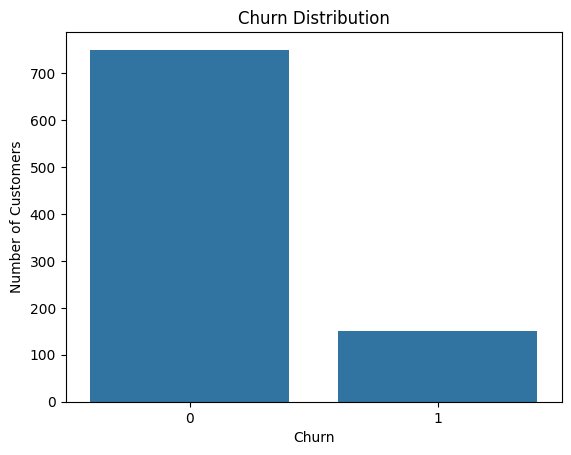

In [9]:
# visualizing the distribution of the Churn variable
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.savefig("../images/churn_distribution.png", bbox_inches="tight")
plt.show()

The target variable is Churn. A value of 1 means the customer left, while 0 means the customer stayed. Checking the distribution helps understand whether the dataset is balanced or imbalanced.

## Exploratory Data Analysis Questions

1. Are older customers more likely to churn?
2. Does total purchase amount affect churn?
3. Are customers with more years less likely to churn?
4. Does the number of sites influence churn?
5. Does having an account manager reduce churn?

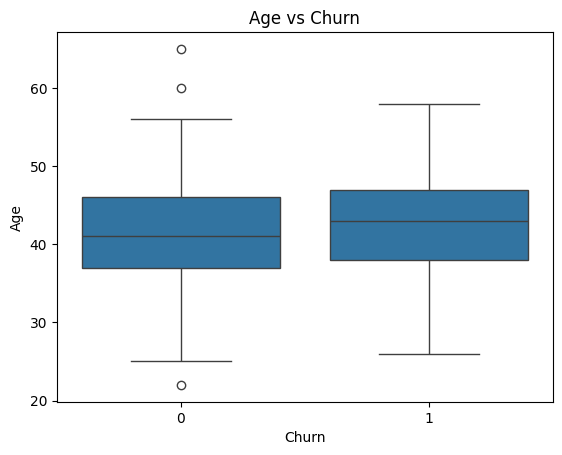

In [10]:
# visualizing the relationship between Age and Churn
sns.boxplot(data=df, x="Churn", y="Age")
plt.title("Age vs Churn")
plt.savefig("../images/age_vs_churn.png", bbox_inches="tight")
plt.show()

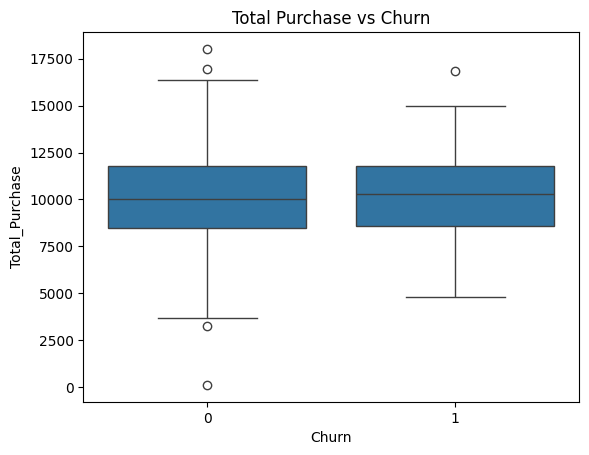

In [11]:
# visualizing the relationship between Total_Purchase and Churn
sns.boxplot(data=df, x="Churn", y="Total_Purchase")
plt.title("Total Purchase vs Churn")
plt.savefig("../images/total_purchase_vs_churn.png", bbox_inches="tight")
plt.show()

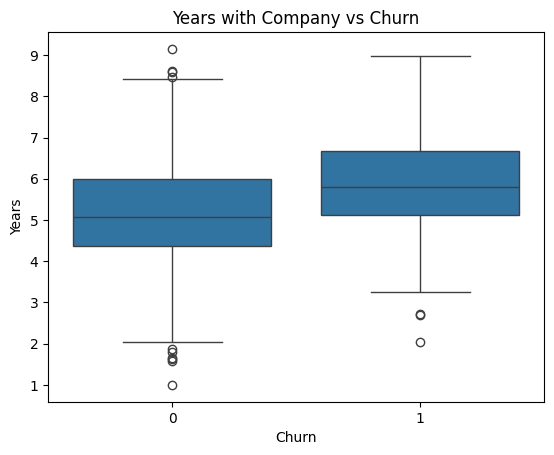

In [12]:
# visualizing the relationship between Years with Company and Churn
sns.boxplot(data=df, x="Churn", y="Years")
plt.title("Years with Company vs Churn")
plt.savefig("../images/years_vs_churn.png", bbox_inches="tight")
plt.show()

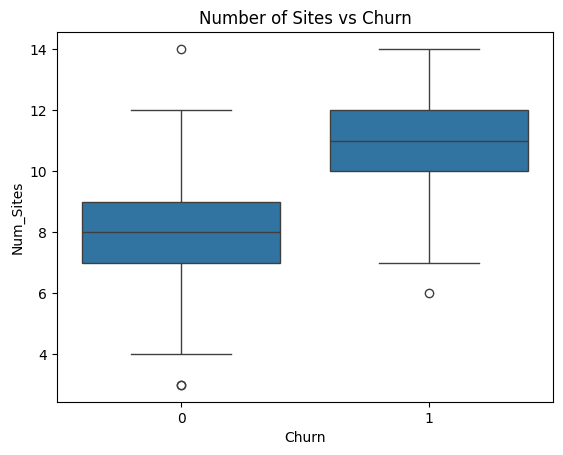

In [13]:
# visualizing the relationship between Number of Sites and Churn
sns.boxplot(data=df, x="Churn", y="Num_Sites")
plt.title("Number of Sites vs Churn")
plt.savefig("../images/num_sites_vs_churn.png", bbox_inches="tight")
plt.show()

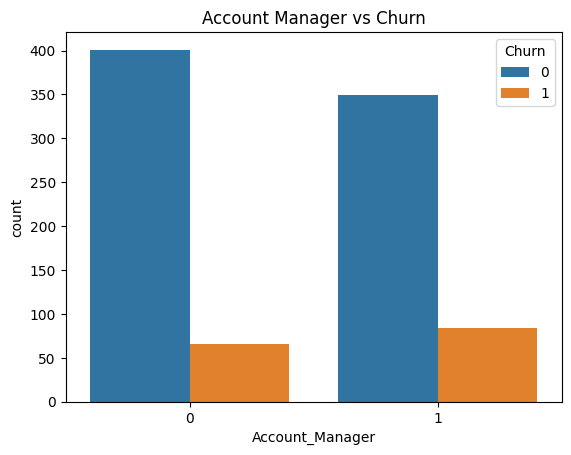

In [14]:
# visualizing the relationship between Account Manager and Churn
sns.countplot(data=df, x="Account_Manager", hue="Churn")
plt.title("Account Manager vs Churn")
plt.savefig("../images/account_manager_vs_churn.png", bbox_inches="tight")
plt.show()

## Data cleaning

In [15]:
# checking the columns of the dataset
df.columns

Index(['Names', 'Age', 'Total_Purchase', 'Account_Manager', 'Years',
       'Num_Sites', 'Onboard_date', 'Location', 'Company', 'Churn'],
      dtype='str')

In [16]:
# preparing the data for modeling by dropping irrelevant columns
df_model = df.drop(["Names", "Location", "Company", "Onboard_date"], axis=1)
df_model.head()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
0,42.0,11066.80,0,7.22,8.0,1
1,41.0,11916.22,0,6.50,11.0,1
2,38.0,12884.75,0,6.67,12.0,1
3,42.0,8010.76,0,6.71,10.0,1
4,37.0,9191.58,0,5.56,9.0,1


In [17]:
df_model.isnull().sum()

Age                0
Total_Purchase     0
Account_Manager    0
Years              0
Num_Sites          0
Churn              0
dtype: int64

The columns Names, Location, Company, and Onboard_date were removed from the first model because they are text-based identifiers. This first version focuses on numerical customer behavior features.

## Train first model

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [19]:
# separating features and target variable
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

In [20]:
# splitting the data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
# standardizing the features using StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
# training a logistic regression model
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [23]:
# making predictions on the test set
y_pred = log_model.predict(X_test_scaled)

In [24]:
# evaluating the model's performance using accuracy score
accuracy_score(y_test, y_pred)

0.9055555555555556

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94       150
           1       0.81      0.57      0.67        30

    accuracy                           0.91       180
   macro avg       0.86      0.77      0.81       180
weighted avg       0.90      0.91      0.90       180



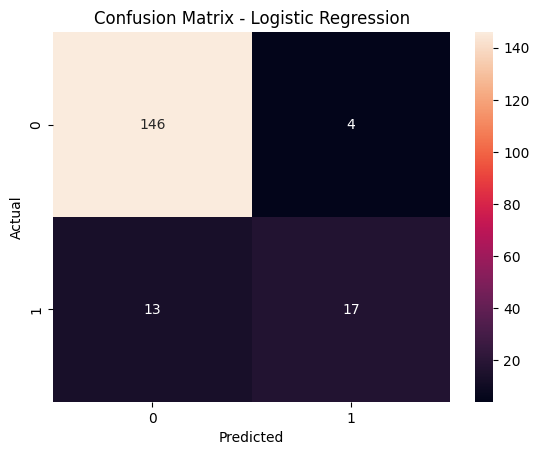

In [26]:
# visualizing the confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../images/confusion_matrix_logistic_regression.png", bbox_inches="tight")
plt.show()

The confusion matrix helps show how many customers were correctly and incorrectly classified as churned or not churned. For churn prediction, identifying actual churn customers is very important because the business wants to take early action.

## Train second model for comparison

In [27]:
from sklearn.ensemble import RandomForestClassifier

In [28]:
# training a random forest classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [29]:
accuracy_score(y_test, rf_pred)

0.8722222222222222

In [30]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.90      0.95      0.93       150
           1       0.65      0.50      0.57        30

    accuracy                           0.87       180
   macro avg       0.78      0.72      0.75       180
weighted avg       0.86      0.87      0.87       180



In [31]:
#model evaluation and comparison
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ]
})

model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.905556,0.809524,0.566667,0.666667
1,Random Forest,0.872222,0.652174,0.500000,0.566038


## Model Comparison

Both Logistic Regression and Random Forest were tested to compare model performance.  
For churn prediction, recall is especially important because the business wants to identify customers who are likely to leave.

In [32]:
# calculating ROC-AUC scores for both models
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, log_prob))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_prob))

Logistic Regression ROC-AUC: 0.9133333333333333
Random Forest ROC-AUC: 0.8953333333333333


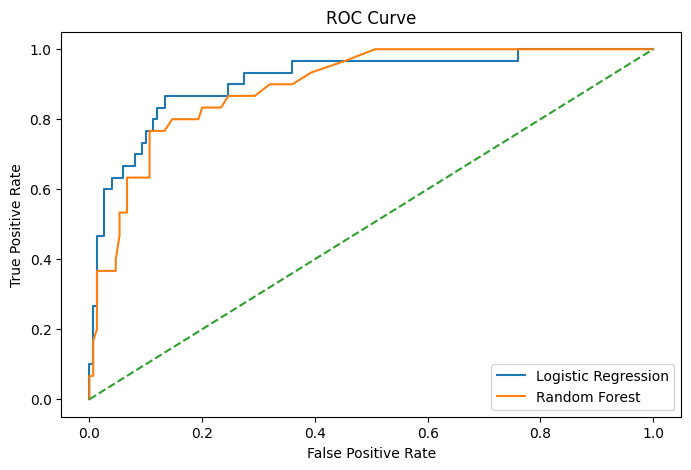

In [33]:
from sklearn.metrics import roc_curve

log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8, 5))
plt.plot(log_fpr, log_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("../images/roc_curve.png", bbox_inches="tight")
plt.show()

## ROC-AUC Evaluation

ROC-AUC helps evaluate how well the model separates churned and non-churned customers. A higher ROC-AUC score means the model is better at ranking customers by churn risk.

## Feature importance

In [34]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
4,Num_Sites,0.380731
3,Years,0.255726
1,Total_Purchase,0.184649
0,Age,0.147170
2,Account_Manager,0.031724


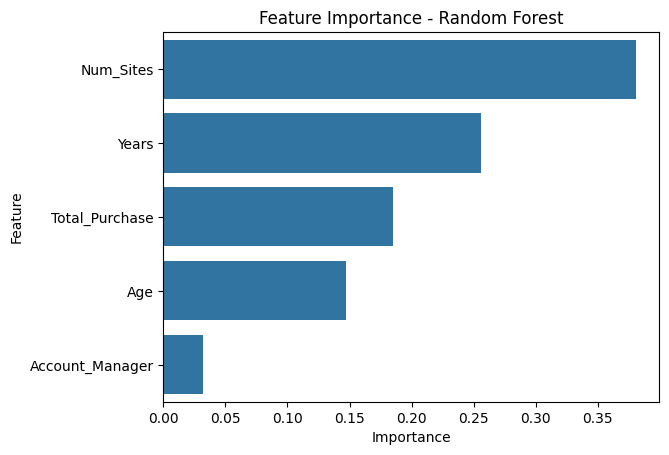

In [35]:
# visualizing feature importance
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")
plt.savefig("../images/feature_importance.png", bbox_inches="tight")
plt.show()

Feature importance shows which variables contributed most to the Random Forest model. These factors can help the business understand which customer characteristics are linked with churn risk.

## Final Business Insights

Based on the analysis and model results:

- Customers with a higher number of sites showed stronger churn risk.
- Customer tenure and total purchase amount provided useful signals for churn prediction.
- The model can help the company identify customers who may need additional support.
- Churn prediction can support better customer retention strategies by helping the business act before customers leave.

In [36]:
import pickle
with open("../models/random_forest_churn_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

## Predict Churn Risk for New Customers

After training the final model, it can be used to predict churn risk for new customers who do not have a churn label yet.

In [37]:
new_customers = pd.read_csv("../data/new_customers_1.csv")
new_customers.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company
0,Andrew Mccall,37.0,9935.53,1,7.71,8.0,2011-08-29 18:37:54,38612 Johnny Stravenue Nataliebury WI 15717-8316,King Ltd
1,Michele Wright,23.0,7526.94,1,9.28,15.0,2013-07-22 18:19:54,"21083 Nicole Junction Suite 332, Youngport ME ...",Cannon-Benson
2,Jeremy Chang,65.0,100.00,1,1.00,15.0,2006-12-11 07:48:13,085 Austin Views Lake Julialand WY 63726-4298,Barron-Robertson
3,Megan Ferguson,32.0,6487.50,0,9.40,14.0,2016-10-28 05:32:13,922 Wright Branch North Cynthialand NC 64721,Sexton-Golden
4,Taylor Young,32.0,13147.71,1,10.00,8.0,2012-03-20 00:36:46,Unit 0789 Box 0734 DPO AP 39702,Wood LLC


In [38]:
# preparing the new customer data for prediction by dropping irrelevant columns
new_customers_model = new_customers.drop(
    ["Names", "Location", "Company", "Onboard_date"],
    axis=1
)

In [39]:
# making predictions on the new customer data using the trained random forest model
new_predictions = rf_model.predict(new_customers_model)
new_probabilities = rf_model.predict_proba(new_customers_model)[:, 1]

In [40]:
# adding the predictions and probabilities to the new customer dataframe
new_customers["Predicted_Churn"] = new_predictions
new_customers["Churn_Probability"] = new_probabilities

new_customers[["Names", "Company", "Predicted_Churn", "Churn_Probability"]]

,Names,Company,Predicted_Churn,Churn_Probability
0,Andrew Mccall,King Ltd,0,0.03
1,Michele Wright,Cannon-Benson,1,0.75
2,Jeremy Chang,Barron-Robertson,0,0.43
3,Megan Ferguson,Sexton-Golden,1,0.57
4,Taylor Young,Wood LLC,0,0.31
5,Jessica Drake,Parks-Robbins,0,0.32


In [41]:
# saving the new customer predictions to a CSV file
new_customers.to_csv("../data/new_customer_churn_predictions.csv", index=False)

## Model Conclusion

The Random Forest model was selected as the final model because it performed well and also provided feature importance values. These feature importance values help explain which customer characteristics are most useful for predicting churn.

The model can be used by a business team to identify customers with higher churn probability and take early retention actions.